In [1]:
# Name: Amirshayan Hamidin
# Course: CSC 647/747
# Assignment: Coding Project 1 - Single Qubit Systems
# Date: 2026-02-09

In [2]:
print("Jupyter + Python is working")

Jupyter + Python is working


In [3]:
!pip install qiskit qiskit-aer matplotlib

In [4]:
import qiskit
print("Qiskit version:", qiskit.__version__)

Qiskit version: 2.3.0


In [15]:
from qiskit import QuantumCircuit

qc1 = QuantumCircuit(1, 1)  # 1 qubit, 1 normla bit

In [14]:
qc1.measure(0, 0)

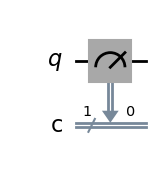

In [7]:
qc1.draw("mpl")

In [8]:
!pip install pylatexenc

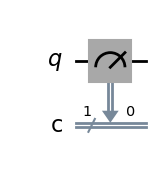

In [13]:
qc1.draw("mpl")

### Circuit 1 Explanation

This circuit initializes a single qubit in the default |0⟩ state and measures it into a classical bit. Since no quantum gates are applied, the measurement outcome is deterministic.111

In [16]:
from qiskit import QuantumCircuit

# Statevector circuit (NO measurement)
qc1_sv = QuantumCircuit(1)

In [18]:
from qiskit.quantum_info import Statevector

statevector = Statevector.from_instruction(qc1_sv)
print(statevector)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


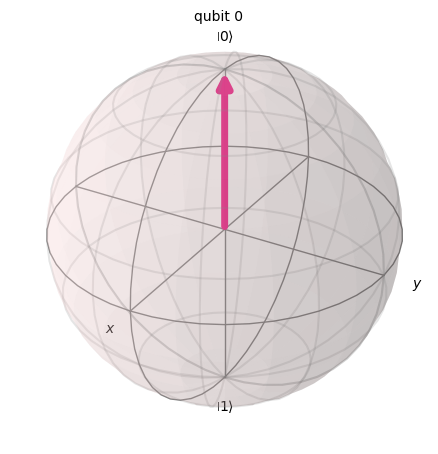

In [19]:
from qiskit.visualization import plot_bloch_multivector

plot_bloch_multivector(statevector)

In [24]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer

# Measurement circuit
qc1 = QuantumCircuit(1, 1)
qc1.measure(0, 0)

backend = Aer.get_backend('qasm_simulator')
job = backend.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts()
print(counts)

{'0': 1024}


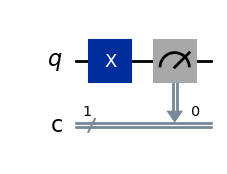

In [25]:
# Circuit 2: State inversion
qc2 = QuantumCircuit(1, 1)
qc2.x(0)
qc2.measure(0, 0)
qc2.draw("mpl")

In [26]:
# Statevector-only circuit
qc2_sv = QuantumCircuit(1)
qc2_sv.x(0)

statevector_2 = Statevector.from_instruction(qc2_sv)
print(statevector_2)

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


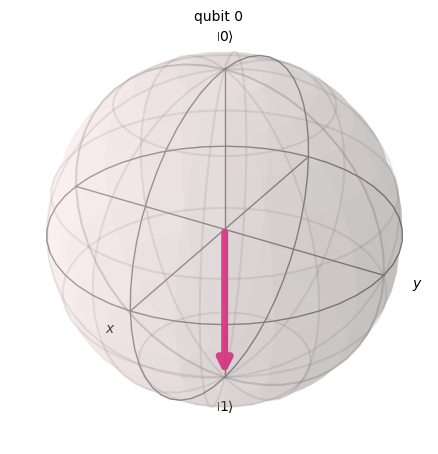

In [27]:
plot_bloch_multivector(statevector_2)

In [28]:
backend = Aer.get_backend('qasm_simulator')
job = backend.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts()

print(counts)

{'1': 1024}


Circuit 2 Explanation

This circuit initializes a single qubit in the |0⟩ state and applies a Pauli-X gate, which inverts the quantum state to |1⟩. The statevector confirms that the final state is |1⟩ with probability 1. The Bloch Sphere visualization shows the qubit at the south pole, corresponding to |1⟩. When measured 1024 times, all outcomes are ‘1’, indicating a deterministic measurement result.

Observed/measured value:
The qubit is observed in the |1⟩ state with probability 1.

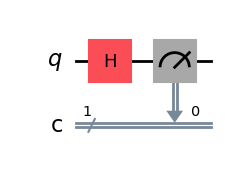

In [29]:
# Circuit 3: Superposition
qc3 = QuantumCircuit(1, 1)

# Apply Hadamard gate
qc3.h(0)

# Measurement
qc3.measure(0, 0)

qc3.draw("mpl")

In [30]:
# Statevector-only circuit
qc3_sv = QuantumCircuit(1)
qc3_sv.h(0)

statevector_3 = Statevector.from_instruction(qc3_sv)
print(statevector_3)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


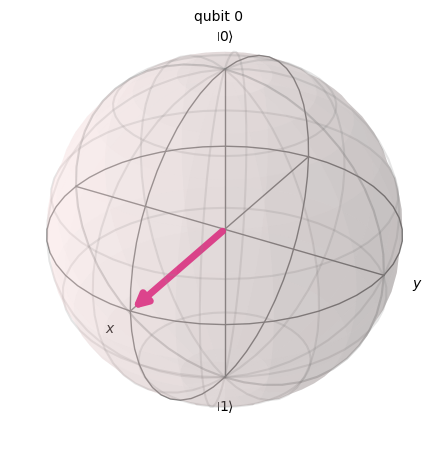

In [31]:
plot_bloch_multivector(statevector_3)

In [32]:
backend = Aer.get_backend('qasm_simulator')
job = backend.run(qc3, shots=1024)
result = job.result()
counts_3 = result.get_counts()

print(counts_3)

{'1': 511, '0': 513}


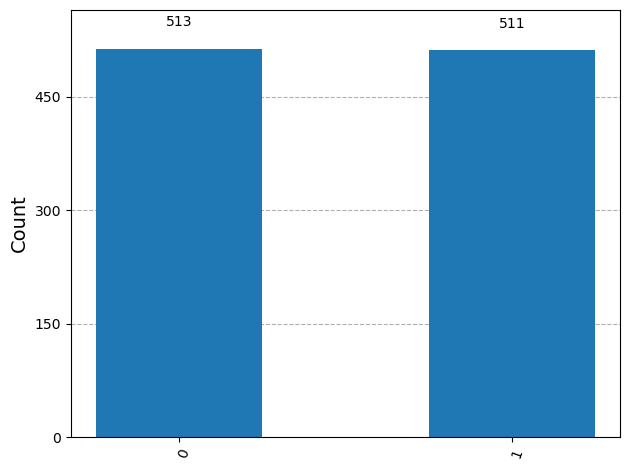

In [34]:
from qiskit.visualization import plot_histogram

plot_histogram(counts_3)

In [35]:
for i in range(3):
    job = backend.run(qc3, shots=1024)
    result = job.result()
    counts = result.get_counts()
    print(f"Run {i+1}:", counts)

Run 1: {'0': 510, '1': 514}
Run 2: {'0': 516, '1': 508}
Run 3: {'1': 496, '0': 528}


Circuit 3 Explanation

This circuit initializes a single qubit in the |0⟩ state and applies a Hadamard gate, creating a superposition state with equal probabilities of measuring |0⟩ and |1⟩. The statevector confirms equal probability amplitudes for both basis states. The Bloch Sphere visualization shows the qubit aligned along the +X axis, indicating superposition. When measured multiple times, the counts fluctuate due to the probabilistic nature of quantum measurement, but approach a 50/50 distribution as the number of shots increases. ( Edited with ChatGPT)

Question: Do you see the same results each time? Why or why not?

The Bloch Sphere and statevector results remain the same across executions because they describe the underlying quantum state before measurement. However, the measurement counts differ slightly each time due to the inherent randomness of quantum measurement. As the number of shots increases, the measured distribution converges toward equal probabilities for |0⟩ and |1⟩.

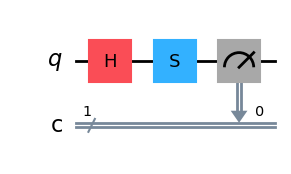

In [37]:
# Circuit 4: +Y direction on Bloch sphere
qc4 = QuantumCircuit(1, 1)

qc4.h(0)   # Move from +Z to +X
qc4.s(0)   # Rotate from +X to +Y

qc4.measure(0, 0)

qc4.draw("mpl")

In [38]:
qc4_sv = QuantumCircuit(1)
qc4_sv.h(0)
qc4_sv.s(0)

statevector_4 = Statevector.from_instruction(qc4_sv)
print(statevector_4)

Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


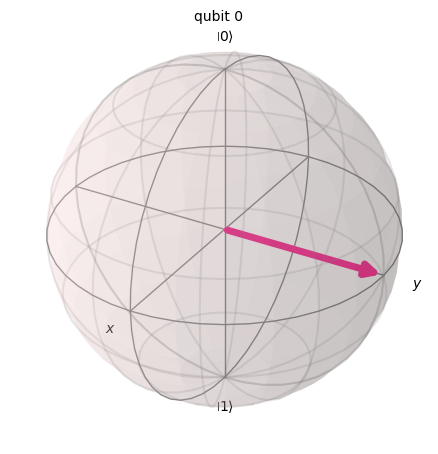

In [39]:
from qiskit.visualization import plot_bloch_multivector

plot_bloch_multivector(statevector_4)

In [40]:
backend = Aer.get_backend('qasm_simulator')
job = backend.run(qc4, shots=1024)
result = job.result()
counts_4 = result.get_counts()

print(counts_4)

{'0': 505, '1': 519}


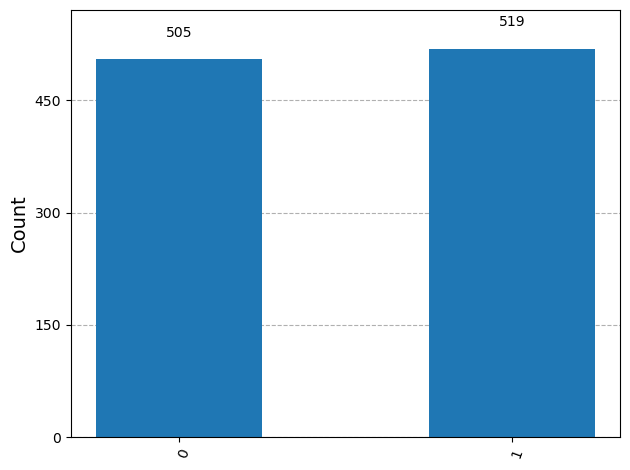

In [41]:
plot_histogram(counts_4)

Circuit 4 Explanation

This circuit initializes a single qubit in the |0⟩ state and applies a Hadamard gate followed by a phase (S) gate. The Hadamard gate moves the state from the +Z axis to the +X axis on the Bloch Sphere, and the phase gate rotates the state from +X to +Y. The resulting statevector is 
(
∣
0
⟩
+
𝑖
∣
1
⟩
)
/
2
(∣0⟩+i∣1⟩)/
2
	​

, which is confirmed by the Bloch Sphere visualization showing the state pointing along the +Y axis. Measurement results show approximately equal probabilities for |0⟩ and |1⟩.

Question: What is the observed/measured value of the quantum state?

Although the Bloch Sphere shows the qubit aligned along the +Y axis, measurement in the computational basis yields probabilistic outcomes of |0⟩ and |1⟩ with approximately equal probability. The relative phase information is lost upon measurement, which is why the counts resemble those of a superposition state along the X axis.

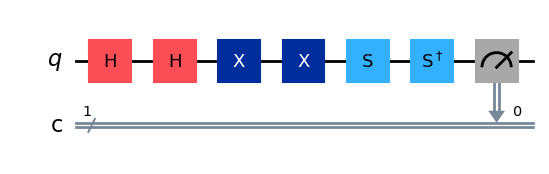

In [42]:
# Circuit 5: Identity using mixed single-qubit gates
qc5 = QuantumCircuit(1, 1)

qc5.h(0)
qc5.h(0)

qc5.x(0)
qc5.x(0)

qc5.s(0)
qc5.sdg(0)

qc5.measure(0, 0)

qc5.draw("mpl")

In [43]:
qc5_sv = QuantumCircuit(1)

qc5_sv.h(0)
qc5_sv.h(0)

qc5_sv.x(0)
qc5_sv.x(0)

qc5_sv.s(0)
qc5_sv.sdg(0)

statevector_5 = Statevector.from_instruction(qc5_sv)
print(statevector_5)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


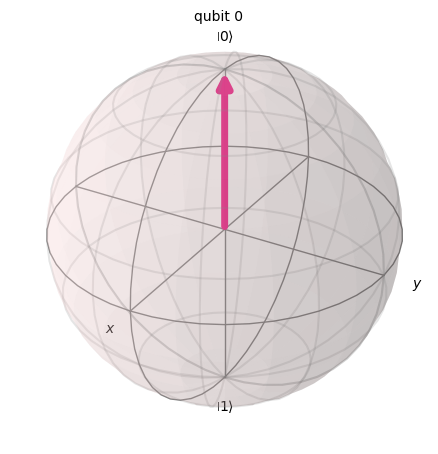

In [44]:
plot_bloch_multivector(statevector_5)

In [45]:
backend = Aer.get_backend('qasm_simulator')
job = backend.run(qc5, shots=1024)
result = job.result()
counts_5 = result.get_counts()

print(counts_5)

{'0': 1024}


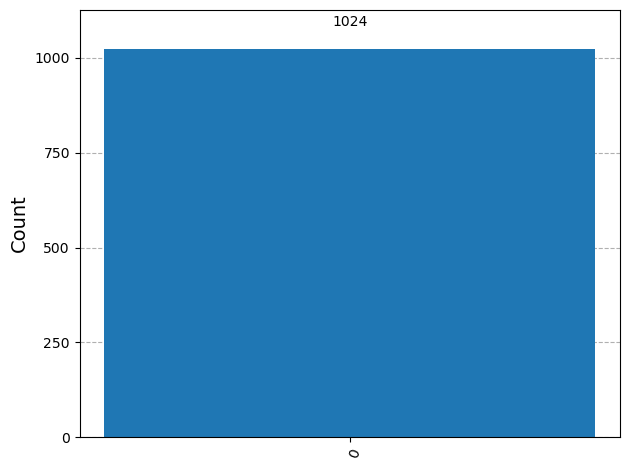

In [46]:
plot_histogram(counts_5)

Circuit 5 Explanation

This circuit implements the identity transformation using an even number of mixed single-qubit gates. P of gates that are self inverse (H, X) or inverse to each other (S and S†) are applied sequentially, causing their effects to cancel. Although multiple non-identity gates are used, the overall transformation leaves the quantum state unchanged. Statevector analysis and Bloch Sphere visualization confirm that the final state remains |0⟩, and measurement results show deterministic outcomes.(ChatGPT HELPED WRITING)